In [51]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from warnings import filterwarnings

import altair as alt
alt.data_transformers.enable('default', max_rows=None)

DataTransformerRegistry.enable('default')

In [52]:
filterwarnings("ignore")

In [53]:
def get_sse(X, labels):
    sse = 0
    for l in np.unique(labels):
        c = np.mean(X[labels == l], axis=0)
        sse += np.sum(cdist(np.expand_dims(c, axis=0), X[labels == l]) ** 2)
    return sse


def get_bss(X, labels):
    cluster_centers = list()
    for l in np.unique(labels):
        c = np.mean(X[labels == l], axis=0)
        cluster_centers.append(c)
    cluster_centers = np.array(cluster_centers)
    _, sizes = np.unique(labels, return_counts=True)
    m = np.mean(X, axis=0)
    bss = np.sum(sizes * cdist(np.expand_dims(m, axis=0), cluster_centers) ** 2)
    return bss


def eval_clustering(X, labels):
    sse = get_sse(X[labels != -1], labels[labels != -1])
    bss = get_bss(X[labels != -1], labels[labels != -1])
    silh = silhouette_score(X[labels != -1], labels[labels != -1])
    return sse, bss, silh

In [54]:
df_macro = pd.read_csv("Macro_sports.csv")

In [55]:
df_country_profile = df_macro.groupby(['country_noc', 'country']).agg(
    total_gold        = ('gold',          'sum'),
    total_silver      = ('silver',        'sum'),
    total_bronze      = ('bronze',        'sum'),
    total_medals      = ('total_medals',  'sum'),
    n_sports          = ('sport',         'nunique'),
    n_editions        = ('year',          'nunique'),
    athletes_total    = ('num_athletes',  'sum'),
).reset_index()

In [56]:
df_country_profile['medals_per_edition'] = (
    df_country_profile['total_medals'] / df_country_profile['n_editions']
)

df_country_profile['gold_ratio'] = (
    df_country_profile['total_gold'] / df_country_profile['total_medals']
).fillna(0)

In [57]:
df_country_profile

,country_noc,country,total_gold,total_silver,total_bronze,total_medals,n_sports,n_editions,athletes_total,medals_per_edition,gold_ratio
0,AFG,Afghanistan,0,0,2,2,7,11,62,0.181818,0.000000
1,AHO,Netherlands Antilles,0,1,0,1,10,11,50,0.090909,0.000000
2,ALB,Albania,0,0,0,0,8,9,65,0.000000,0.000000
3,ALG,Algeria,5,4,8,17,23,14,415,1.214286,0.294118
4,AND,Andorra,0,0,0,0,8,12,52,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
211,VNM,South Vietnam,0,0,0,0,7,3,30,0.000000,0.000000
212,YEM,Yemen,0,0,0,0,7,8,36,0.000000,0.000000
213,YUG,Yugoslavia,21,19,25,65,25,7,394,9.285714,0.323077
214,ZAM,Zambia,0,1,1,2,8,14,144,0.142857,0.000000


In [58]:
df_country_profile.describe()

,total_gold,total_silver,total_bronze,total_medals,n_sports,n_editions,athletes_total,medals_per_edition,gold_ratio
count,216.000000,216.000000,216.000000,216.000000,216.000000,216.000000,216.000000,216.000000,216.000000
mean,17.541667,17.541667,19.629630,54.712963,17.680556,10.939815,424.689815,6.306986,0.152781
std,55.209016,47.433362,47.811469,149.218588,13.397841,3.539950,693.237911,17.915120,0.183938
min,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,5.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,8.000000,57.000000,0.000000,0.000000
50%,0.000000,1.000000,1.000000,3.000000,13.000000,12.000000,135.500000,0.258333,0.000000
75%,8.000000,11.250000,16.250000,35.250000,27.000000,14.000000,429.000000,3.312500,0.284731
max,589.000000,481.000000,430.000000,1500.000000,55.000000,15.000000,4791.000000,122.666667,1.000000


In [59]:
df_country_profile = df_country_profile[df_country_profile['total_medals'] >= 10]
print(df_country_profile.shape)

(80, 11)


In [60]:
features = ['total_gold', 'total_silver', 'total_bronze', 'total_medals',
            'n_sports', 'n_editions', 'athletes_total',
            'medals_per_edition', 'gold_ratio']

corr = df_country_profile[features].corr()
corr

,total_gold,total_silver,total_bronze,total_medals,n_sports,n_editions,athletes_total,medals_per_edition,gold_ratio
total_gold,1.000000,0.985855,0.956815,0.990890,0.490673,-0.000898,0.783995,0.734212,0.411308
total_silver,0.985855,1.000000,0.980023,0.997160,0.552955,0.025873,0.845117,0.724012,0.360767
total_bronze,0.956815,0.980023,1.000000,0.985906,0.596839,0.047548,0.893853,0.693554,0.346824
total_medals,0.990890,0.997160,0.985906,1.000000,0.547581,0.022582,0.844240,0.724813,0.378906
n_sports,0.490673,0.552955,0.596839,0.547581,1.000000,0.167106,0.783467,0.369250,0.125412
n_editions,-0.000898,0.025873,0.047548,0.022582,0.167106,1.000000,0.288758,-0.468416,-0.106315
athletes_total,0.783995,0.845117,0.893853,0.844240,0.783467,0.288758,1.000000,0.448567,0.245211
medals_per_edition,0.734212,0.724012,0.693554,0.724813,0.369250,-0.468416,0.448567,1.000000,0.403390
gold_ratio,0.411308,0.360767,0.346824,0.378906,0.125412,-0.106315,0.245211,0.403390,1.000000


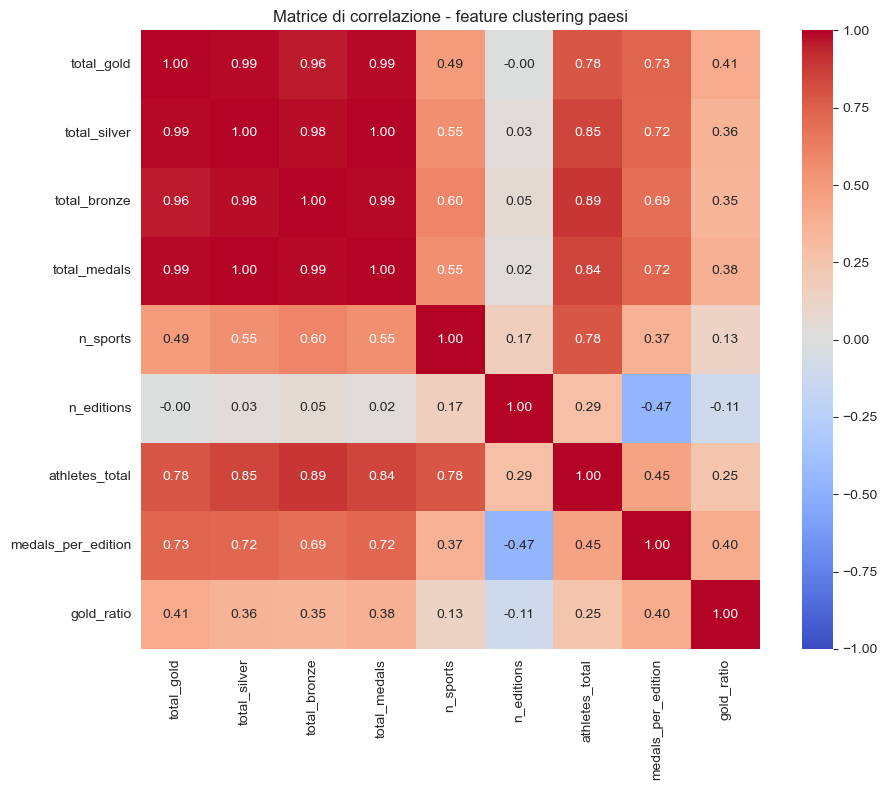

In [61]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, square=True)
plt.title('Matrice di correlazione - feature clustering paesi')
plt.tight_layout()
plt.show()

In [62]:
feat_for_clust = ['total_medals', 'medals_per_edition', 'gold_ratio', 'n_sports', 'n_editions']

In [63]:
X = df_country_profile[feat_for_clust]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [64]:
kmin = 2
kmax = 10

krange = np.arange(kmin, kmax, 1)

results = {
    "sse": list(),
    "bss": list(),
    "silh": list()
}

for k in krange:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    labels = kmeans.labels_
    sse, bss, silh = eval_clustering(X_scaled, labels)
    results["sse"].append(sse)
    results["bss"].append(bss)
    results["silh"].append(silh)

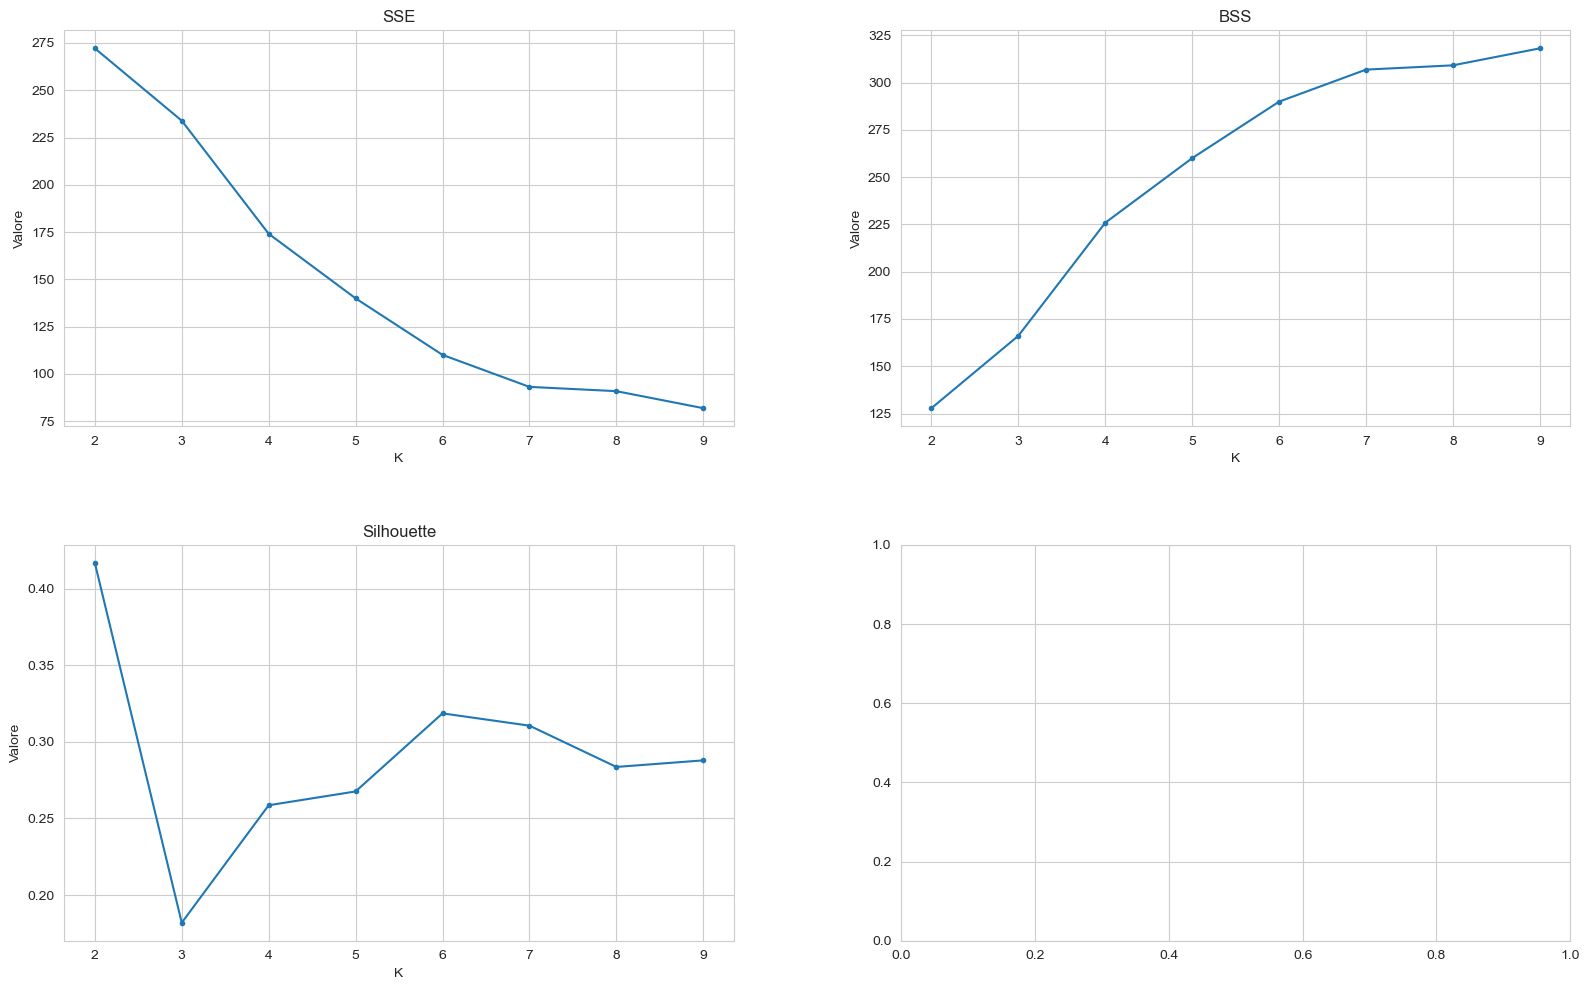

In [65]:
metrics = ["sse", "bss", "silh"]
titles = ["SSE", "BSS", "Silhouette"]
nrows = 2
ncols = 2

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 10))
axes = axes.flatten()

for i, metrica in enumerate(metrics):
    ax = axes[i]
    ax.plot(krange, results[metrica], marker=".")
    ax.set_title(titles[i])
    ax.set_xlabel("K")
    ax.set_ylabel("Valore")
    ax.grid(True)

plt.tight_layout()
plt.subplots_adjust(hspace=0.3, wspace=0.25)
plt.show()

In [66]:
n_clust_2 = KMeans(n_clusters=2,  random_state=42)
n_clust_2.fit(X_scaled)
df_country_profile['cluster_k2'] = n_clust_2.labels_

In [67]:
labels, sizes = np.unique(n_clust_2.labels_, return_counts=True)
for l, s in zip(labels, sizes):
    print("Cluster %s: %d (%.2f)" % (l, s, s/len(X)))

Cluster 0: 65 (0.81)
Cluster 1: 15 (0.19)


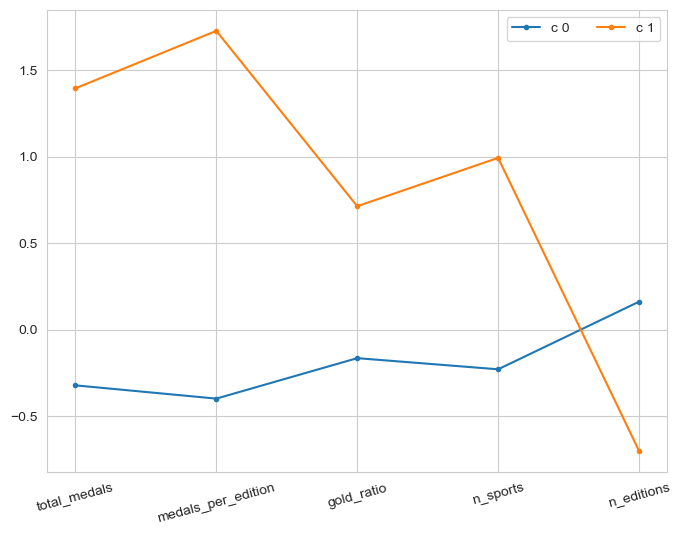

In [68]:
plt.figure(figsize=(8, 6))
for c in np.unique(n_clust_2.labels_):
    plt.plot(feat_for_clust, n_clust_2.cluster_centers_[c], marker='.', label='c %s' % c)

plt.xticks(rotation=15)
plt.legend(ncol=4)
plt.grid(True)
plt.show()

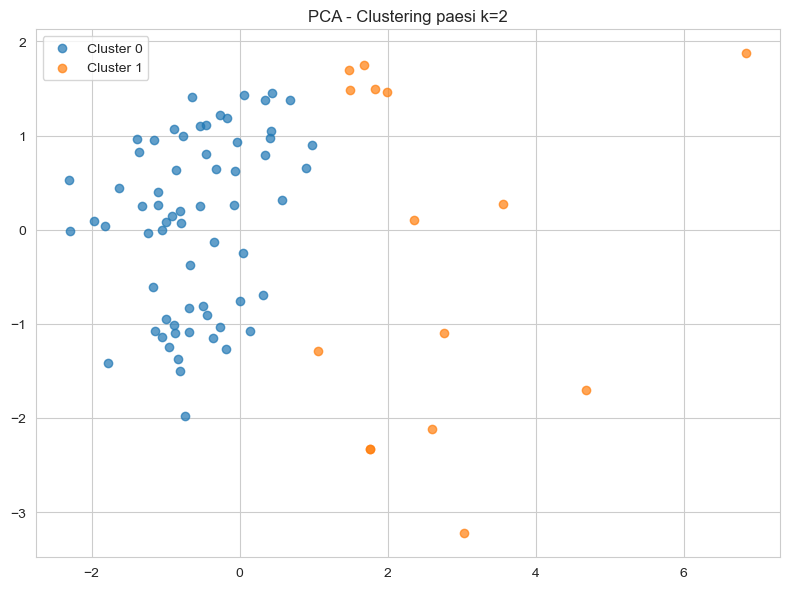

In [69]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
fig, ax = plt.subplots(figsize=(8, 6))

for c in sorted(df_country_profile['cluster_k2'].unique()):
    mask = df_country_profile['cluster_k2'] == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], label=f'Cluster {c}', alpha=0.7)

ax.set_title('PCA - Clustering paesi k=2')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

In [70]:
for k in sorted(df_country_profile['cluster_k2'].unique()):
    sports = df_country_profile[df_country_profile['cluster_k2'] == k]['country'].tolist()
    print(f"\nCluster {k}:")
    print(sports)


Cluster 0:
['Algeria', 'Argentina', 'Armenia', 'Austria', 'Azerbaijan', 'The Bahamas', 'Belgium', 'Belarus', 'Brazil', 'Bulgaria', 'Canada', 'Colombia', 'Croatia', 'Cuba', 'Czechia', 'Denmark', 'Dominican Republic', 'Egypt', 'Spain', 'Estonia', 'Ethiopia', 'Finland', 'Georgia', 'Greece', 'Hungary', 'Indonesia', 'India', 'Islamic Republic of Iran', 'Ireland', 'Israel', 'Jamaica', 'Kazakhstan', 'Kenya', 'Republic of Korea', 'Latvia', 'Lithuania', 'Morocco', 'Malaysia', 'Mexico', 'Mongolia', 'Netherlands', 'Nigeria', 'Norway', 'New Zealand', 'Poland', 'Portugal', "Democratic People's Republic of Korea", 'Romania', 'South Africa', 'Slovenia', 'Serbia', 'Switzerland', 'Slovakia', 'Sweden', 'Czechoslovakia', 'Thailand', 'Chinese Taipei', 'Trinidad and Tobago', 'Tunisia', 'Türkiye', 'Uganda', 'Ukraine', 'Uzbekistan', 'Venezuela', 'Yugoslavia']

Cluster 1:
['Australia', "People's Republic of China", 'Unified Team', 'France', 'West Germany', 'Great Britain', 'East Germany', 'Germany', 'Italy',

Cluster 1 — Le superpotenze olimpiche

USA, URSS, Cina, Germania (Est e Ovest), Russia, Gran Bretagna, Francia, Australia, Italia, Giappone — le nazioni che hanno dominato la storia olimpica. Tante medaglie totali, tante medaglie per edizione, alto gold ratio, tanti sport. L'unica anomalia è n_editions bassa, cosa che dipende dal fatto che URSS, Germania Est e Unified Team esistevano solo in certi periodi storici.


Cluster 0 — Il resto del mondo

Tutti gli altri paesi che partecipano da molte edizioni ma con volumi di medaglie molto più bassi.

In [71]:
n_clust_6 = KMeans(n_clusters=6,  random_state=42)
n_clust_6.fit(X_scaled)
df_country_profile['cluster_k6'] = n_clust_6.labels_

In [72]:
labels, sizes = np.unique(n_clust_6.labels_, return_counts=True)
for l, s in zip(labels, sizes):
    print("Cluster %s: %d (%.2f)" % (l, s, s / len(X)))

Cluster 0: 20 (0.25)
Cluster 1: 22 (0.28)
Cluster 2: 15 (0.19)
Cluster 3: 8 (0.10)
Cluster 4: 1 (0.01)
Cluster 5: 14 (0.17)


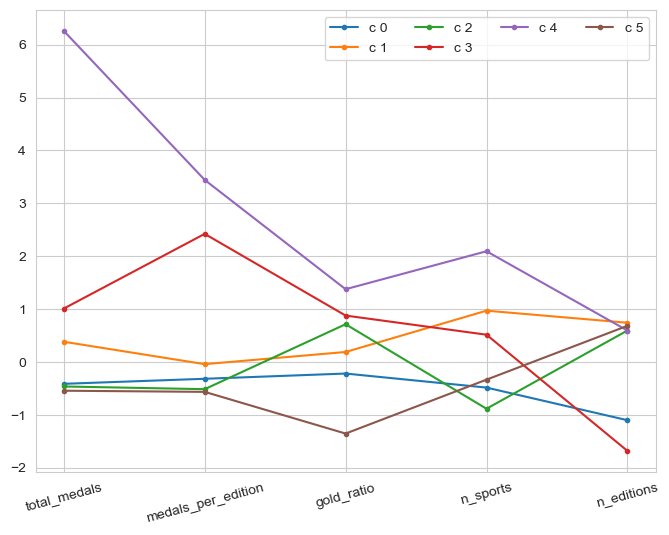

In [73]:
plt.figure(figsize=(8, 6))
for c in np.unique(n_clust_6.labels_):
    plt.plot(feat_for_clust, n_clust_6.cluster_centers_[c], marker='.', label='c %s' % c)

plt.xticks(rotation=15)
plt.legend(ncol=4)
plt.grid(True)
plt.show()

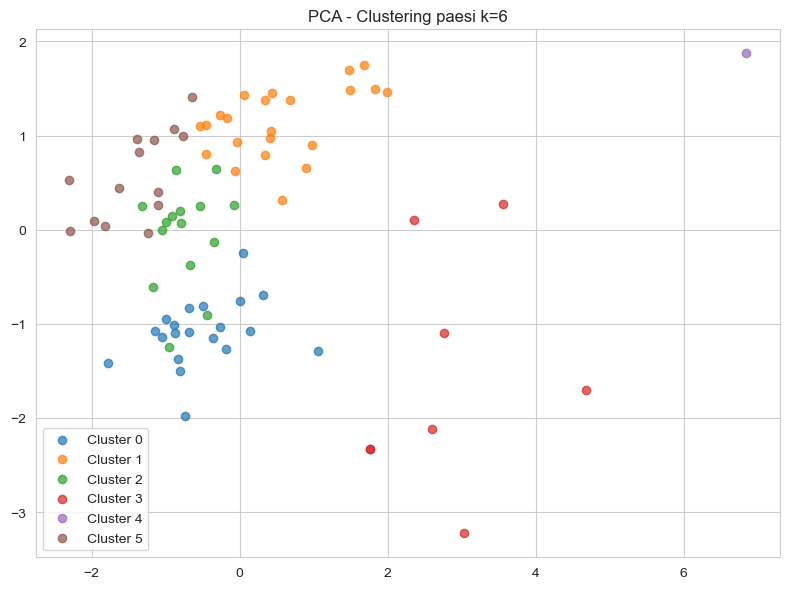

In [74]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
fig, ax = plt.subplots(figsize=(8, 6))

for c in sorted(df_country_profile['cluster_k6'].unique()):
    mask = df_country_profile['cluster_k6'] == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], label=f'Cluster {c}', alpha=0.7)

ax.set_title('PCA - Clustering paesi k=6')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

In [75]:
for k in sorted(df_country_profile['cluster_k6'].unique()):
    sports = df_country_profile[df_country_profile['cluster_k6'] == k]['country'].tolist()
    print(f"\nCluster {k}:")
    print(sports)


Cluster 0:
['Armenia', 'Azerbaijan', 'Belarus', 'Croatia', 'Czechia', 'Estonia', 'West Germany', 'Georgia', 'Kazakhstan', 'Latvia', 'Lithuania', "Democratic People's Republic of Korea", 'South Africa', 'Slovenia', 'Serbia', 'Slovakia', 'Czechoslovakia', 'Ukraine', 'Uzbekistan', 'Yugoslavia']

Cluster 1:
['Argentina', 'Australia', 'Belgium', 'Brazil', 'Bulgaria', 'Canada', 'Cuba', 'Denmark', 'Spain', 'France', 'Great Britain', 'Greece', 'Hungary', 'Italy', 'Japan', 'Republic of Korea', 'Netherlands', 'New Zealand', 'Poland', 'Romania', 'Switzerland', 'Sweden']

Cluster 2:
['Algeria', 'The Bahamas', 'Dominican Republic', 'Ethiopia', 'Finland', 'Islamic Republic of Iran', 'Ireland', 'Jamaica', 'Kenya', 'Morocco', 'Norway', 'Thailand', 'Tunisia', 'Türkiye', 'Uganda']

Cluster 3:
["People's Republic of China", 'Unified Team', 'East Germany', 'Germany', 'ROC', 'Russian Olympic Committee', 'Russian Federation', 'Soviet Union']

Cluster 4:
['United States']

Cluster 5:
['Austria', 'Colombia',

Cluster 4 — USA da soli

Gli Stati Uniti sono talmente anomali rispetto a tutti gli altri che K-Means li isola in un cluster da soli, un outlier assoluto per volume di medaglie.

Cluster 3 — Le ex potenze del blocco sovietico + Cina e Germania

URSS, Germania Est, Russia, ROC, Cina, Germania unificata: paesi con tantissime medaglie per edizione, alto gold ratio ma poche edizioni (perché alcune esistevano solo in certi periodi storici). Il "secondo polo" della Guerra Fredda olimpica.

Cluster 1 — Potenze olimpiche consolidate

Australia, Francia, Gran Bretagna, Italia, Giappone, Corea del Sud, Ungheria, Cuba, Brasil, ecc.: paesi con buon volume di medaglie, tanti sport, tante edizioni. Le nazioni olimpicamente mature.

Cluster 0 — Paesi dell'ex blocco sovietico minori

Armenia, Azerbaijan, Ucraina, Kazakhstan, Croazia, Slovacchia, ecc.: paesi nati dalla dissoluzione dell'URSS e Jugoslavia, poche edizioni ma discreti risultati.

Cluster 2 — Specialisti e paesi emergenti

Jamaica, Kenya, Etiopia, Marocco, Cuba, Algeria, Turchia: paesi che vincono in pochi sport specifici ma con ottima efficienza. Poche medaglie totali ma molto concentrate.

Cluster 5 — Partecipanti con medaglie sporadiche

India, Indonesia, Messico, Nigeria, Colombia: paesi grandi per popolazione ma con poche medaglie, poco costanti.

In [76]:
for k in sorted(df_country_profile['cluster_k6'].unique()):
    countries = df_country_profile[df_country_profile['cluster_k6'] == k]['country'].tolist()
    print(f"\nCluster {k} ({len(countries)} paesi):")
    for c in sorted(countries):
        print(f"  - {c}")


Cluster 0 (20 paesi):
  - Armenia
  - Azerbaijan
  - Belarus
  - Croatia
  - Czechia
  - Czechoslovakia
  - Democratic People's Republic of Korea
  - Estonia
  - Georgia
  - Kazakhstan
  - Latvia
  - Lithuania
  - Serbia
  - Slovakia
  - Slovenia
  - South Africa
  - Ukraine
  - Uzbekistan
  - West Germany
  - Yugoslavia

Cluster 1 (22 paesi):
  - Argentina
  - Australia
  - Belgium
  - Brazil
  - Bulgaria
  - Canada
  - Cuba
  - Denmark
  - France
  - Great Britain
  - Greece
  - Hungary
  - Italy
  - Japan
  - Netherlands
  - New Zealand
  - Poland
  - Republic of Korea
  - Romania
  - Spain
  - Sweden
  - Switzerland

Cluster 2 (15 paesi):
  - Algeria
  - Dominican Republic
  - Ethiopia
  - Finland
  - Ireland
  - Islamic Republic of Iran
  - Jamaica
  - Kenya
  - Morocco
  - Norway
  - Thailand
  - The Bahamas
  - Tunisia
  - Türkiye
  - Uganda

Cluster 3 (8 paesi):
  - East Germany
  - Germany
  - People's Republic of China
  - ROC
  - Russian Federation
  - Russian Olympic Commi

Paesi e sport

In [77]:
df_success = pd.read_csv("Success_score_country_sport.csv")
print(df_success.shape)
print(df_success.head())

(3780, 6)
  country_noc      sport  success_score_mean  total_golds  total_athletes  \
0         AFG  Athletics                 0.0          0.0              12   
1         AFG     Boxing                 0.0          0.0               5   
2         AFG       Judo                 0.0          0.0               3   
3         AFG   Shooting                 0.0          0.0               1   
4         AFG   Swimming                 0.0          0.0               1   

   success_score_overall  
0                    0.0  
1                    0.0  
2                    0.0  
3                    0.0  
4                    0.0  


In [78]:
pivot = df_success.pivot_table(
    index='country_noc',
    columns='sport',
    values='success_score_overall',
    fill_value=0
)

print(pivot.shape)
print(pivot.head())

(215, 55)
sport        3x3 Basketball  Archery  Artistic Gymnastics  Artistic Swimming  \
country_noc                                                                    
AFG                     0.0      0.0                  0.0                0.0   
AHO                     0.0      0.0                  0.0                0.0   
ALB                     0.0      0.0                  0.0                0.0   
ALG                     0.0      0.0                  0.0                0.0   
AND                     0.0      0.0                  0.0                0.0   

sport        Athletics  Badminton  Baseball  Basketball  Basque pelota  \
country_noc                                                              
AFG            0.00000        0.0       0.0         0.0            0.0   
AHO            0.00000        0.0       0.0         0.0            0.0   
ALB            0.00000        0.0       0.0         0.0            0.0   
ALG            0.02963        0.0       0.0         0.0    

In [79]:
countries_to_keep = df_country_profile['country_noc'].tolist()
pivot = pivot[pivot.index.isin(countries_to_keep)]
print(pivot.shape)

(79, 55)


In [80]:
pivot

sport,3x3 Basketball,Archery,Artistic Gymnastics,Artistic Swimming,Athletics,Badminton,Baseball,Basketball,Basque pelota,Beach Volleyball,...,Taekwondo,Tennis,Trampolining,Triathlon,Volleyball,Water Polo,Waterskiing,Weightlifting,Wrestling,Wushu
country_noc,,,,,,,,,,,,,,,,,,,,,
ALG,0.0,0.000000,0.000000,0.000000,0.029630,0.0,0.000,0.000000,0.0,0.000000,...,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0
ARG,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000,0.166667,0.0,0.000000,...,0.125000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0
ARM,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000,0.000000,0.0,0.000000,...,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.037736,0.0
AUS,0.0,0.020000,0.000000,0.000000,0.014876,0.0,0.000,0.000000,0.0,0.071429,...,0.030303,0.017544,0.0,0.028571,0.000000,0.052632,0.0,0.015625,0.000000,0.0
AUT,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000,0.000000,0.0,0.000000,...,0.000000,0.000000,0.0,0.058824,0.000000,0.000000,0.0,0.000000,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
URS,0.0,0.052632,0.583333,0.000000,0.096234,0.0,0.000,0.444444,0.0,0.000000,...,0.000000,0.000000,0.0,0.000000,0.583333,0.333333,0.0,0.549020,0.419643,0.0
USA,1.0,0.119403,0.127273,0.294118,0.098938,0.0,0.125,0.800000,0.0,0.304348,...,0.069767,0.164706,0.0,0.029412,0.166667,0.157895,0.0,0.009615,0.131148,0.0
UZB,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000,0.000000,0.0,0.000000,...,0.066667,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.074074,0.033333,0.0


In [81]:
zeros = (pivot == 0).sum().sum()
total = pivot.shape[0] * pivot.shape[1]
print(f"Valori zero: {zeros}/{total} ({zeros/total*100:.1f}%)")

Valori zero: 3643/4345 (83.8%)


In [82]:
pivot_log = np.log1p(pivot)
X_scaled2 = StandardScaler().fit_transform(pivot_log)

In [83]:
kmin = 2
kmax = 15

krange = np.arange(kmin, kmax, 1)

results = {
    "sse": list(),
    "bss": list(),
    "silh": list()
}

for k in krange:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled2)
    labels = kmeans.labels_
    sse, bss, silh = eval_clustering(X_scaled2, labels)
    results["sse"].append(sse)
    results["bss"].append(bss)
    results["silh"].append(silh)

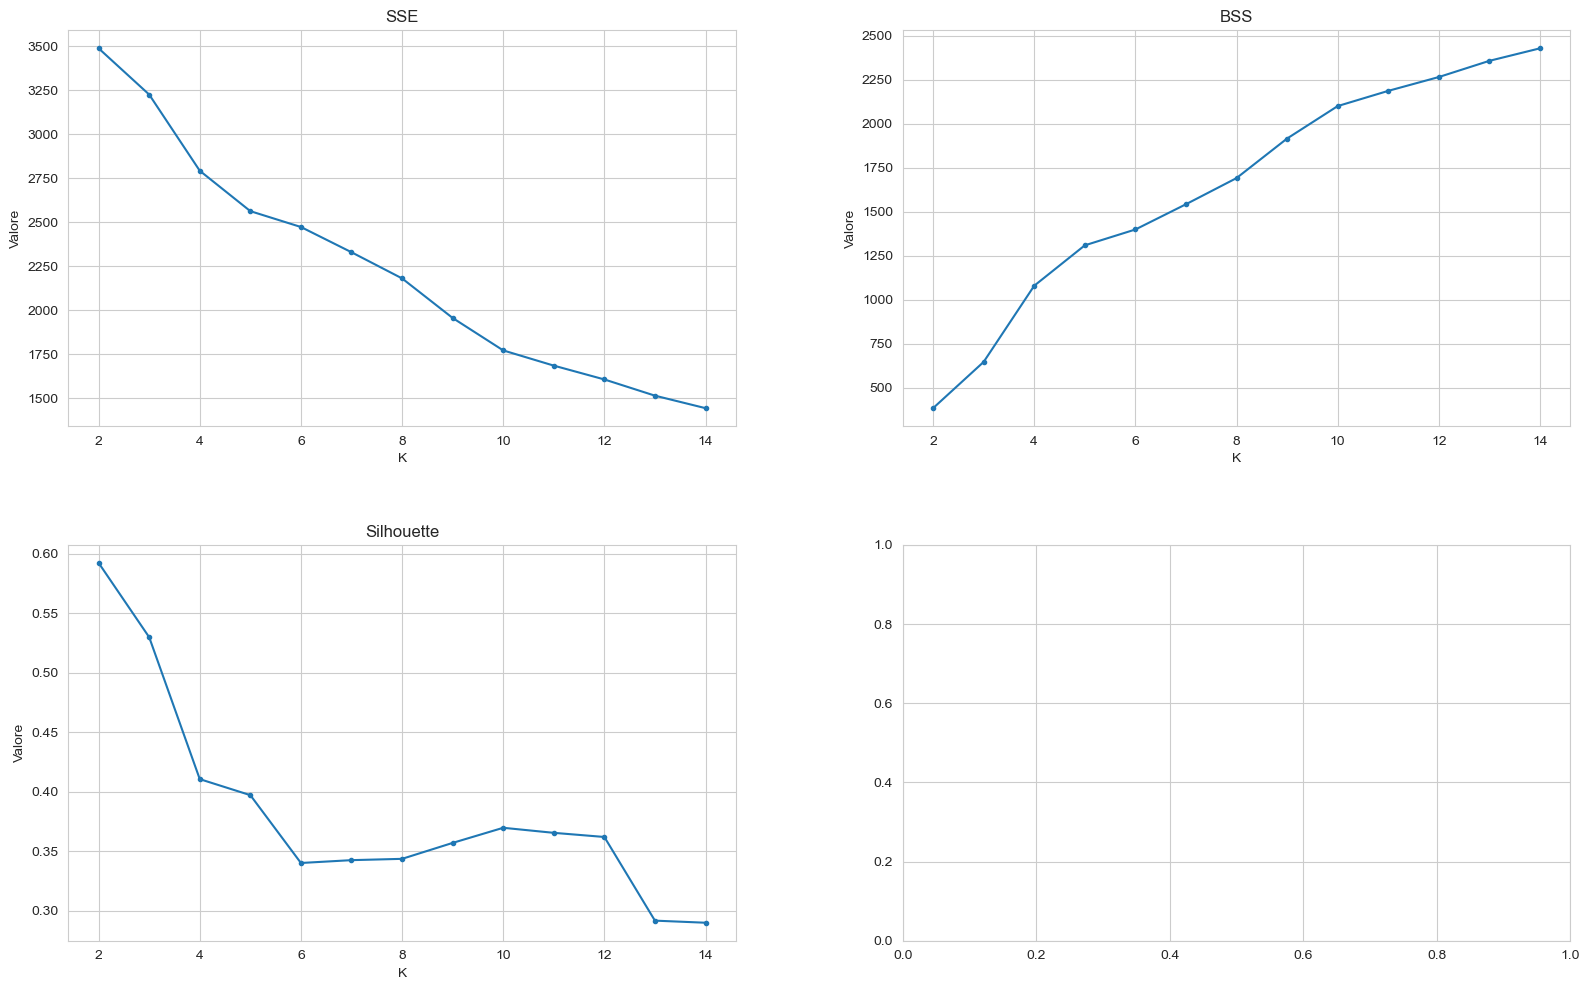

In [84]:
metrics = ["sse", "bss", "silh"]
titles = ["SSE","BSS", "Silhouette"]
nrows = 2
ncols = 2

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 10))
axes = axes.flatten()

for i, metrica in enumerate(metrics):
    ax = axes[i]
    ax.plot(krange, results[metrica], marker=".")
    ax.set_title(titles[i])
    ax.set_xlabel("K")
    ax.set_ylabel("Valore")
    ax.grid(True)

plt.tight_layout()
plt.subplots_adjust(hspace=0.3, wspace=0.25)
plt.show()

In [85]:
n_clust_4 = KMeans(n_clusters=4,  random_state=42)
n_clust_4.fit(X_scaled2)
pivot['cluster_k4'] = n_clust_4.labels_

In [86]:
labels, sizes = np.unique(n_clust_4.labels_, return_counts=True)
for l, s in zip(labels, sizes):
    print("Cluster %s: %d (%.2f)" % (l, s, s/len(X)))

Cluster 0: 11 (0.14)
Cluster 1: 1 (0.01)
Cluster 2: 1 (0.01)
Cluster 3: 66 (0.82)


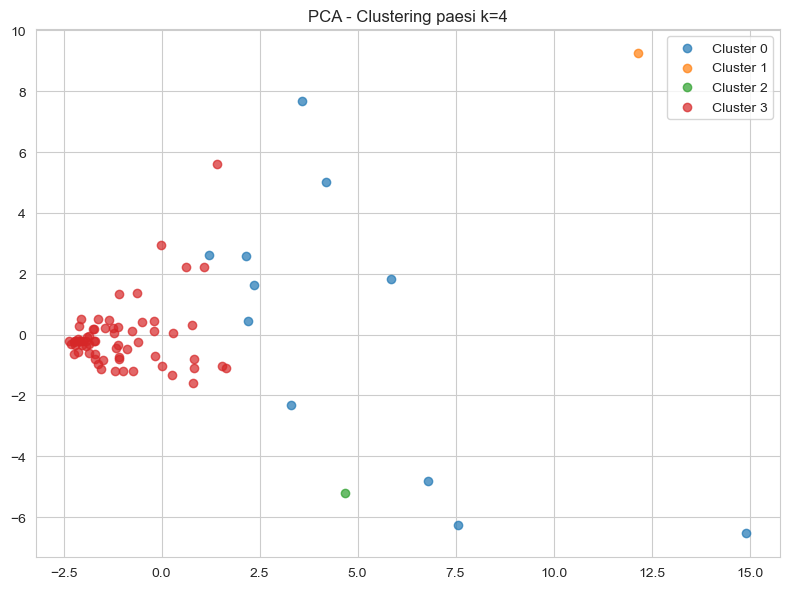

In [87]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled2)
fig, ax = plt.subplots(figsize=(8, 6))

for c in sorted(pivot['cluster_k4'].unique()):
    mask = pivot['cluster_k4'] == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], label=f'Cluster {c}', alpha=0.7)

ax.set_title('PCA - Clustering paesi k=4')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

In [88]:
df_results = pd.DataFrame({
    'country_noc': pivot.index,
    'cluster_k4': pivot['cluster_k4'].values
})

df_results = df_results.merge(
    df_country_profile[['country_noc', 'country']],
    on='country_noc',
    how='left'
)

for k in sorted(df_results['cluster_k4'].unique()):
    countries = df_results[df_results['cluster_k4'] == k]['country'].tolist()
    print(f"\nCluster {k} ({len(countries)} paesi):")
    for c in sorted(countries):
        print(f"  - {c}")


Cluster 0 (12 paesi):
  - East Germany
  - France
  - Germany
  - Great Britain
  - Italy
  - Netherlands
  - ROC
  - Russian Federation
  - Russian Olympic Committee
  - Soviet Union
  - Unified Team
  - West Germany

Cluster 1 (1 paesi):
  - United States

Cluster 2 (1 paesi):
  - People's Republic of China

Cluster 3 (66 paesi):
  - Algeria
  - Argentina
  - Armenia
  - Australia
  - Austria
  - Azerbaijan
  - Belarus
  - Belgium
  - Brazil
  - Bulgaria
  - Canada
  - Chinese Taipei
  - Colombia
  - Croatia
  - Cuba
  - Czechia
  - Czechoslovakia
  - Democratic People's Republic of Korea
  - Denmark
  - Dominican Republic
  - Egypt
  - Estonia
  - Ethiopia
  - Finland
  - Georgia
  - Greece
  - Hungary
  - India
  - Indonesia
  - Ireland
  - Islamic Republic of Iran
  - Israel
  - Jamaica
  - Japan
  - Kazakhstan
  - Kenya
  - Latvia
  - Lithuania
  - Malaysia
  - Mexico
  - Mongolia
  - Morocco
  - New Zealand
  - Nigeria
  - Norway
  - Poland
  - Portugal
  - Republic of Korea
  

In [89]:
for k in sorted(pivot['cluster_k4'].unique()):
    cluster_mask = pivot['cluster_k4'] == k
    sport_cols = [col for col in pivot.columns if col != 'cluster_k4']
    top_sports = pivot[cluster_mask][sport_cols].mean().nlargest(3)
    print(f"\nCluster {k} — top sport:")
    print(top_sports)


Cluster 0 — top sport:
sport
Artistic Swimming      0.204545
Artistic Gymnastics    0.171257
Handball               0.167532
dtype: float64

Cluster 1 — top sport:
sport
3x3 Basketball    1.0
Basketball        0.8
Softball          0.6
dtype: float64

Cluster 2 — top sport:
sport
Diving           0.559524
Table Tennis     0.527273
Weightlifting    0.387755
dtype: float64

Cluster 3 — top sport:
sport
Karate           0.047854
Football         0.034159
Weightlifting    0.029372
dtype: float64


In [90]:
outliers = ['USA', 'CHN']

pivot_filtered = pivot[~pivot.index.isin(outliers)].copy()
pivot_filtered = pivot_filtered.drop(columns=['cluster_k4', 'cluster_k6'], errors='ignore')

print(pivot_filtered.shape)

(77, 55)


In [91]:
pivot_log2 = np.log1p(pivot_filtered)
X_scaled3 = StandardScaler().fit_transform(pivot_log2)

n_clust_4b = KMeans(n_clusters=4, random_state=42)
n_clust_4b.fit(X_scaled3)

pivot_filtered['cluster_k4'] = n_clust_4b.labels_

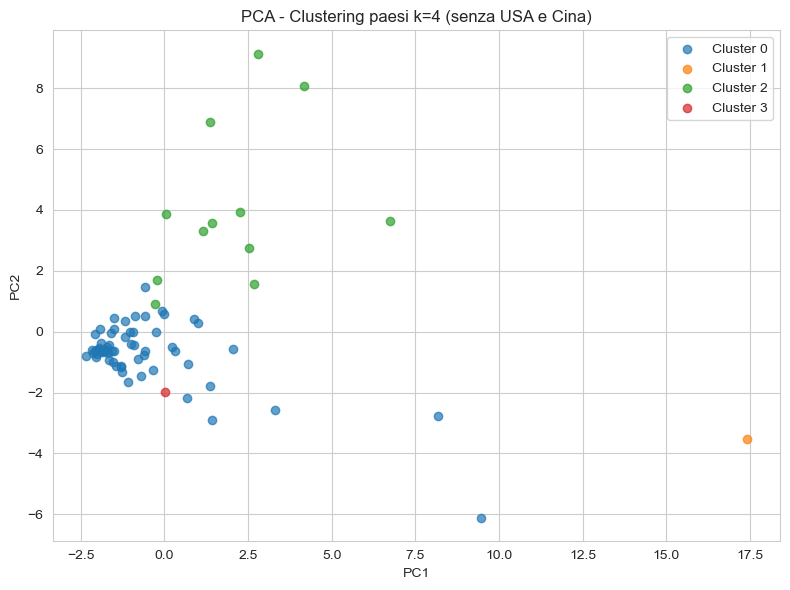

In [92]:
pca = PCA(n_components=2)
X_pca3 = pca.fit_transform(X_scaled3)
fig, ax = plt.subplots(figsize=(8, 6))

for c in sorted(pivot_filtered['cluster_k4'].unique()):
    mask = pivot_filtered['cluster_k4'] == c
    ax.scatter(X_pca3[mask, 0], X_pca3[mask, 1], label=f'Cluster {c}', alpha=0.7)

ax.set_title('PCA - Clustering paesi k=4 (senza USA e Cina)')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

In [93]:
df_results2 = pd.DataFrame({
    'country_noc': pivot_filtered.index,
    'cluster_k4': pivot_filtered['cluster_k4'].values
})

df_results2 = df_results2.merge(
    df_country_profile[['country_noc', 'country']],
    on='country_noc',
    how='left'
)

for k in sorted(df_results2['cluster_k4'].unique()):
    countries = df_results2[df_results2['cluster_k4'] == k]['country'].tolist()
    print(f"\nCluster {k} ({len(countries)} paesi):")
    for c in sorted(countries):
        print(f"  - {c}")


Cluster 0 (64 paesi):
  - Algeria
  - Argentina
  - Armenia
  - Austria
  - Azerbaijan
  - Belarus
  - Belgium
  - Bulgaria
  - Canada
  - Chinese Taipei
  - Colombia
  - Croatia
  - Cuba
  - Czechia
  - Czechoslovakia
  - Democratic People's Republic of Korea
  - Denmark
  - Dominican Republic
  - Egypt
  - Estonia
  - Ethiopia
  - Finland
  - Georgia
  - Greece
  - Hungary
  - India
  - Indonesia
  - Ireland
  - Islamic Republic of Iran
  - Israel
  - Jamaica
  - Japan
  - Kazakhstan
  - Kenya
  - Latvia
  - Lithuania
  - Malaysia
  - Mexico
  - Mongolia
  - Morocco
  - Nigeria
  - Poland
  - Portugal
  - ROC
  - Romania
  - Russian Federation
  - Russian Olympic Committee
  - Serbia
  - Slovakia
  - Slovenia
  - South Africa
  - Sweden
  - Switzerland
  - Thailand
  - The Bahamas
  - Trinidad and Tobago
  - Tunisia
  - Türkiye
  - Uganda
  - Ukraine
  - Unified Team
  - Uzbekistan
  - Venezuela
  - Yugoslavia

Cluster 1 (1 paesi):
  - Soviet Union

Cluster 2 (12 paesi):
  - Austral

In [94]:
sport_cols = [col for col in pivot_filtered.columns if col != 'cluster_k4']

for k in sorted(pivot_filtered['cluster_k4'].unique()):
    mask = pivot_filtered['cluster_k4'] == k
    top_sports = pivot_filtered[mask][sport_cols].mean().nlargest(5)
    print(f"\nCluster {k} — top 5 sport:")
    print(top_sports)


Cluster 0 — top 5 sport:
sport
Karate                 0.042196
Artistic Swimming      0.038360
Weightlifting          0.037361
Artistic Gymnastics    0.036145
Wrestling              0.031434
dtype: float64

Cluster 1 — top 5 sport:
sport
Artistic Gymnastics    0.583333
Volleyball             0.583333
Handball               0.571429
Weightlifting          0.549020
Canoe Sprint           0.510638
dtype: float64

Cluster 2 — top 5 sport:
sport
Rowing           0.122955
Cycling Track    0.122253
Canoe Sprint     0.119189
Football         0.090121
Karate           0.086111
dtype: float64

Cluster 3 — top 5 sport:
sport
Archery      0.450000
Taekwondo    0.235294
Baseball     0.166667
Handball     0.117647
Badminton    0.084507
dtype: float64



Clustering gerarchico, k means non mi convince

In [95]:
sport_cols = [col for col in pivot_filtered.columns if col != 'cluster_k4']
pivot_binary = (pivot_filtered[sport_cols] > 0).astype(int)

In [96]:
from scipy.spatial.distance import pdist, squareform

distances = pdist(pivot_binary.values, metric='jaccard')
dist_matrix = squareform(distances)
print(dist_matrix.shape)

(77, 77)


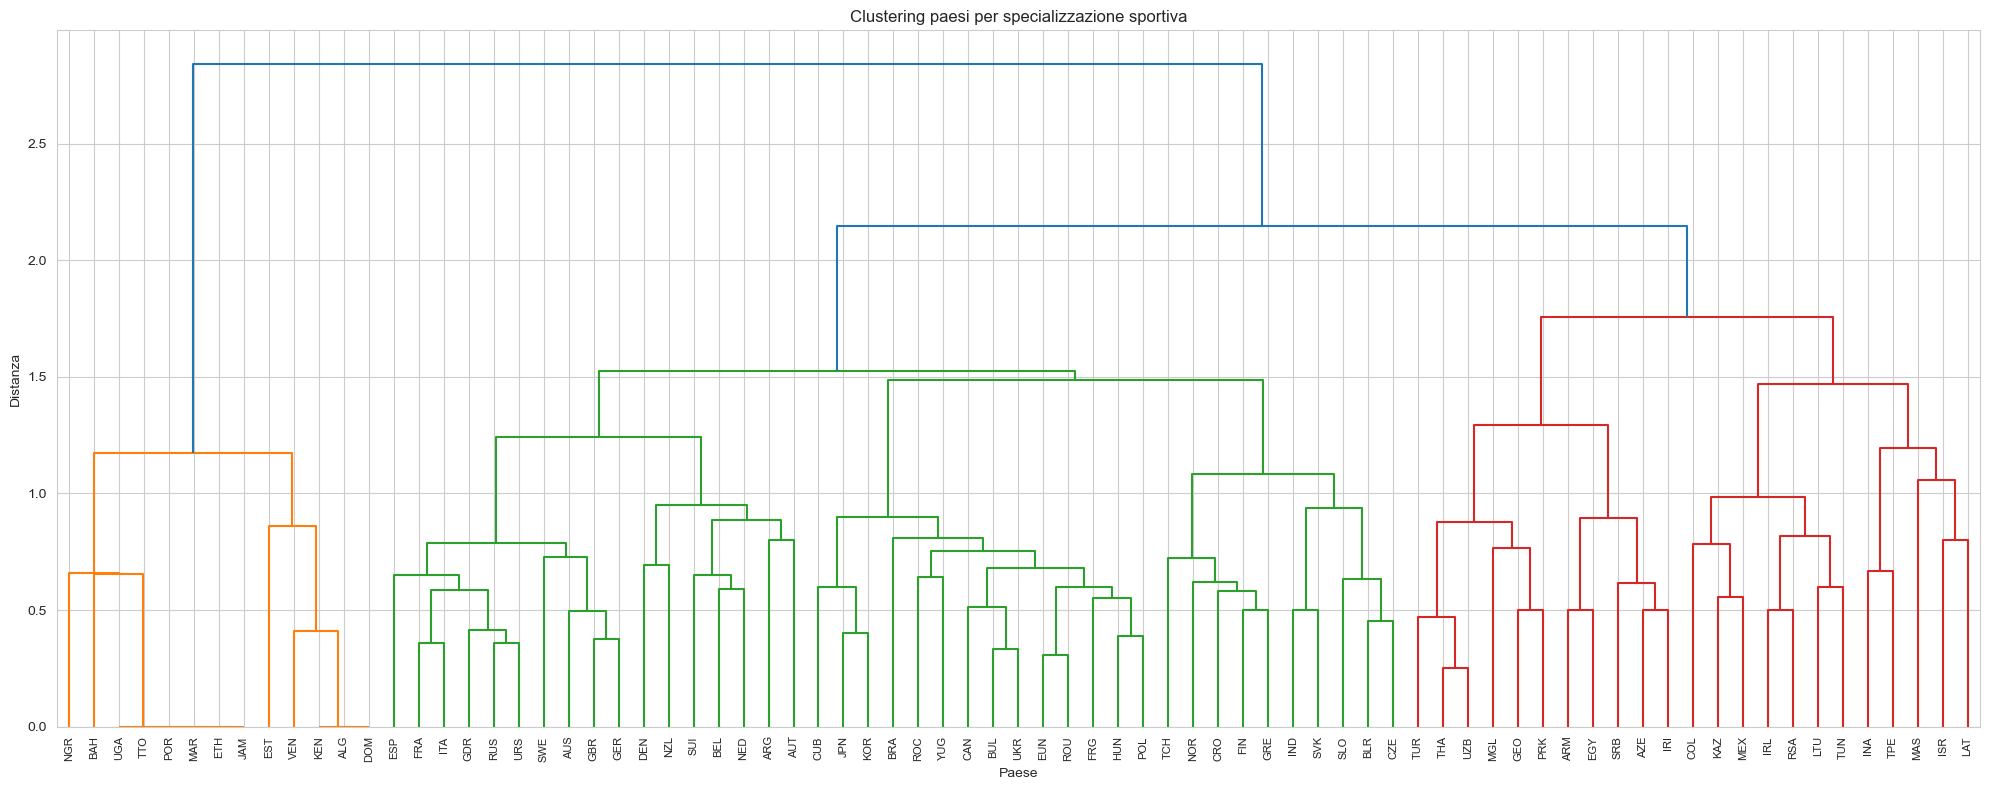

In [97]:
linkage_matrix = linkage(distances, method='ward')

plt.figure(figsize=(20, 8))
dendrogram(
    linkage_matrix,
    labels=pivot_binary.index.tolist(),
    leaf_rotation=90,
    leaf_font_size=8
)
plt.title('Clustering paesi per specializzazione sportiva')
plt.xlabel('Paese')
plt.ylabel('Distanza')
plt.tight_layout()
plt.show()

In [98]:
labels_hier = fcluster(linkage_matrix, t=1.5, criterion='distance')
pivot_binary['cluster_hier'] = labels_hier
print(pd.Series(labels_hier).value_counts())

3    24
2    17
1    13
5    12
4    11
Name: count, dtype: int64


In [99]:
df_results_hier = pd.DataFrame({
    'country_noc': pivot_binary.index,
    'cluster_hier': labels_hier
})

df_results_hier = df_results_hier.merge(
    df_country_profile[['country_noc', 'country']],
    on='country_noc',
    how='left'
)

for k in sorted(df_results_hier['cluster_hier'].unique()):
    countries = df_results_hier[df_results_hier['cluster_hier'] == k]['country'].tolist()
    print(f"\nCluster {k} ({len(countries)} paesi):")
    for c in sorted(countries):
        print(f"  - {c}")


Cluster 1 (13 paesi):
  - Algeria
  - Dominican Republic
  - Estonia
  - Ethiopia
  - Jamaica
  - Kenya
  - Morocco
  - Nigeria
  - Portugal
  - The Bahamas
  - Trinidad and Tobago
  - Uganda
  - Venezuela

Cluster 2 (17 paesi):
  - Argentina
  - Australia
  - Austria
  - Belgium
  - Denmark
  - East Germany
  - France
  - Germany
  - Great Britain
  - Italy
  - Netherlands
  - New Zealand
  - Russian Federation
  - Soviet Union
  - Spain
  - Sweden
  - Switzerland

Cluster 3 (25 paesi):
  - Belarus
  - Brazil
  - Bulgaria
  - Canada
  - Croatia
  - Cuba
  - Czechia
  - Czechoslovakia
  - Finland
  - Greece
  - Hungary
  - India
  - Japan
  - Norway
  - Poland
  - ROC
  - Republic of Korea
  - Romania
  - Russian Olympic Committee
  - Slovakia
  - Slovenia
  - Ukraine
  - Unified Team
  - West Germany
  - Yugoslavia

Cluster 4 (11 paesi):
  - Armenia
  - Azerbaijan
  - Democratic People's Republic of Korea
  - Egypt
  - Georgia
  - Islamic Republic of Iran
  - Mongolia
  - Serbia
  - 

In [100]:
for k in sorted(df_results_hier['cluster_hier'].unique()):
    mask = pivot_binary['cluster_hier'] == k
    top_sports = pivot_binary[mask][sport_cols].mean().nlargest(5)
    print(f"\nCluster {k} — top 5 sport:")
    print(top_sports)


Cluster 1 — top 5 sport:
sport
Athletics        1.000000
Boxing           0.307692
Fencing          0.153846
Cycling Track    0.076923
Football         0.076923
dtype: float64

Cluster 2 — top 5 sport:
sport
Cycling Track    0.882353
Cycling Road     0.823529
Sailing          0.823529
Swimming         0.823529
Athletics        0.764706
dtype: float64

Cluster 3 — top 5 sport:
sport
Athletics              0.958333
Shooting               0.958333
Weightlifting          0.708333
Wrestling              0.708333
Artistic Gymnastics    0.583333
dtype: float64

Cluster 4 — top 5 sport:
sport
Wrestling        0.818182
Taekwondo        0.545455
Weightlifting    0.545455
Boxing           0.454545
Judo             0.454545
dtype: float64

Cluster 5 — top 5 sport:
sport
Athletics              0.500000
Swimming               0.500000
Weightlifting          0.333333
Boxing                 0.250000
Artistic Gymnastics    0.166667
dtype: float64


MAPPA WORK IN PROGRESS!!!

Cluster 1 — Specialisti nell'Atletica leggera

Algeria, Etiopia, Jamaica, Kenya, Marocco, Nigeria, Uganda, Bahamas, Trinidad: paesi africani e caraibici con dominanza assoluta nell'Atletica (100% dei paesi vince in Atletica). Poca diversificazione, ma eccellenza in corsa e sprint.

Cluster 2 — Potenze occidentali diversificate

Francia, Germania, Gran Bretagna, Italia, Australia, Paesi Bassi, Svezia, URSS, Russia: grandi potenze olimpiche con profilo molto diversificato. Eccellono in Ciclismo, Vela, Nuoto, Atletica. Sport che richiedono infrastrutture e investimenti elevati.

Cluster 3 — Potenze est-europee e asiatiche

Bulgaria, Cuba, Cecoslovacchia, Ungheria, Giappone, Polonia, Romania, Yugoslavia, Brasile, Corea del Sud: storiche potenze del blocco orientale più Giappone e Brasile. Atletica e Tiro quasi universali, forti in Pesistica, Lotta e Ginnastica.

Cluster 4 — Specialisti in sport da combattimento

Armenia, Azerbaijan, Georgia, Iran, Mongolia, Turchia, Uzbekistan, Corea del Nord, Egitto, Serbia, Thailandia: paesi dell'Asia Centrale e Medio Oriente con fortissima specializzazione in Lotta, Taekwondo, Pesistica, Boxe e Judo.

Cluster 5 — Partecipanti con profilo misto

Indonesia, Irlanda, Israele, Kazakhstan, Lettonia, Lituania, Malaysia, Messico, Sud Africa, Taiwan: paesi con profilo più eterogeneo, vincono in Atletica e Nuoto ma senza specializzazione netta.